In [1]:
from google.colab import files
import zipfile

uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('unzipped_folder')

print("Extracted Successfully")

Saving archive(1).zip to archive(1).zip
Extracted Successfully


In [2]:
import os

print(os.listdir('unzipped_folder'))

['heart.csv']


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [6]:
df = pd.read_csv("/content/unzipped_folder/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [8]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# model
dt = DecisionTreeClassifier(max_depth=3, random_state=42)

# train
dt.fit(X_train, y_train)

# predict
y_pred = dt.predict(X_test)

# accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))

Decision Tree Accuracy: 0.7804878048780488


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9853658536585366


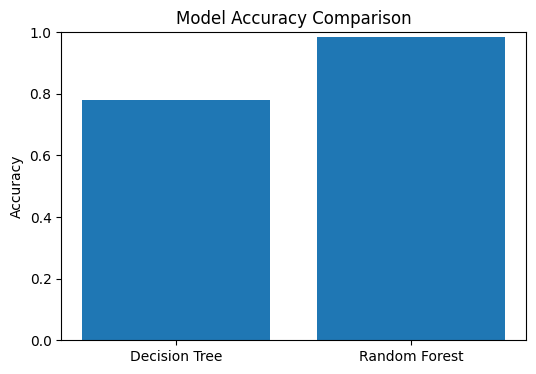

In [11]:
import matplotlib.pyplot as plt

models = ["Decision Tree", "Random Forest"]
accuracies = [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_rf)]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

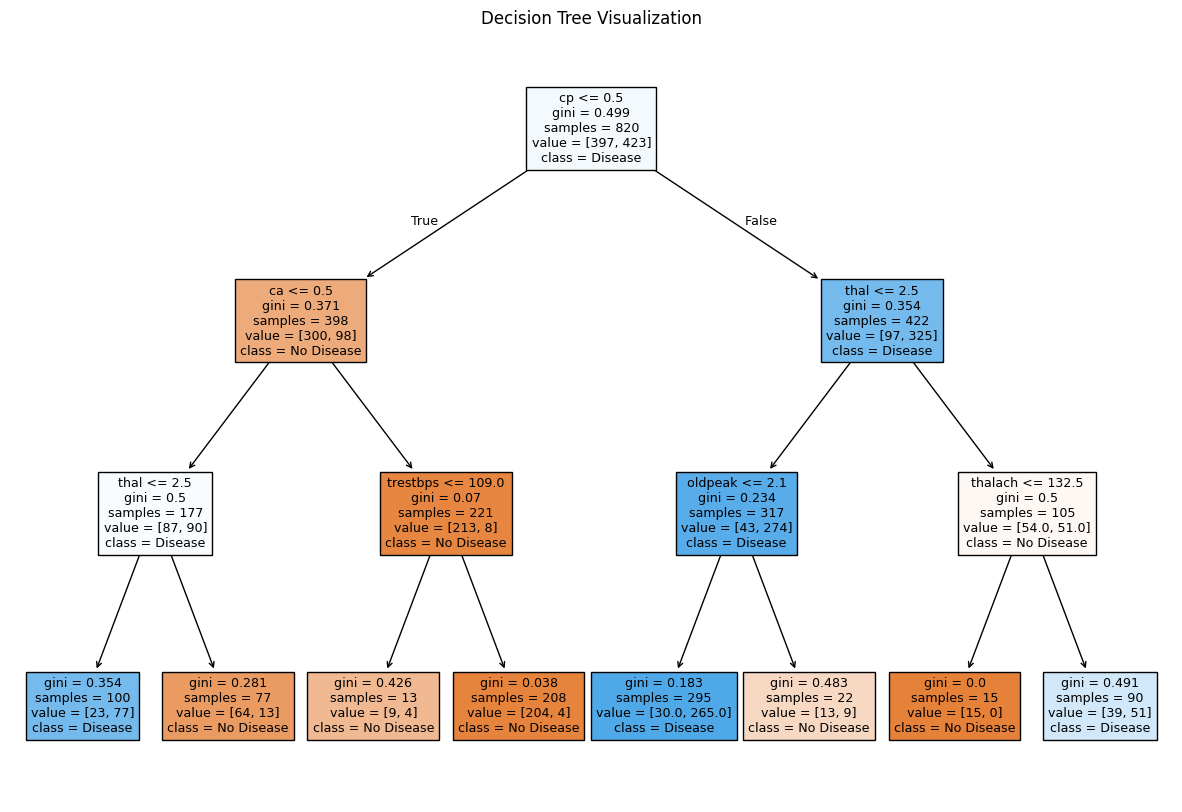

In [12]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plot_tree(dt,
          feature_names=X.columns,
          class_names=["No Disease", "Disease"],
          filled=True)
plt.title("Decision Tree Visualization")
plt.show()

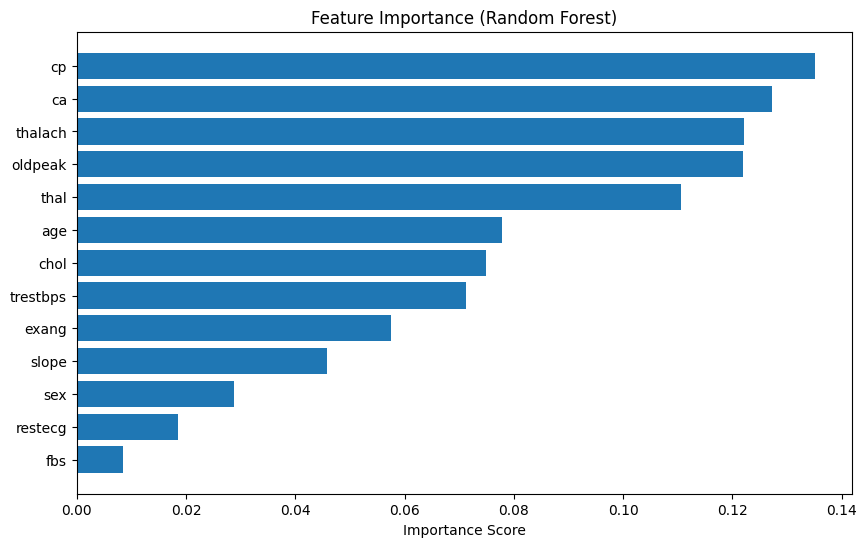

In [13]:
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10,6))
plt.title("Feature Importance (Random Forest)")
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.xlabel("Importance Score")
plt.show()